# Лабораторная работа №2: классификация kNN

**Автор:** Гроза И.В.

## Содержание

1. Анализ постановки задачи
2. План выполнения
3. Бинарная классификация: `weatherAUS.csv`, целевой признак `RainTomorrow`
4. Многоклассовая классификация: `winequality-white.csv`, целевой признак `quality`
5. Итоговые выводы

## Анализ постановки задачи

В работе нужно решить две задачи классификации методом `kNN`:

- бинарную на датасете `weatherAUS.csv` с целью `RainTomorrow`;
- многоклассовую на датасете `winequality-white.csv` с целью `quality`.

Основные ограничения и решения:

- для `weatherAUS` характерны пропуски, категориальные признаки и умеренный дисбаланс классов;
- для `winequality-white` пропусков нет, но есть редкие классы качества, поэтому потребуется балансировка;
- для `kNN` важен масштаб признаков, поэтому нормализация будет сделана явно;
- сравнение моделей будет проводиться по `accuracy`, `precision`, `recall`, `f1-score`, а также через `classification_report`;
- подбор `k` будет выполнен кросс-валидацией на отфильтрованных признаках.

## План выполнения

1. Считать и описать оба датасета.
2. Выполнить очистку данных и кодирование признаков.
3. Зафиксировать разбиение на train/test и снизить дисбаланс только на обучающей части.
4. Для бинарной задачи сравнить `kNN` без нормализации и с нормализацией.
5. Для обеих задач выполнить отбор признаков и повторно обучить модель.
6. Подобрать `k` по кросс-валидации и оценить лучший классификатор на тестовой выборке.

In [63]:
import os
import warnings
from itertools import combinations
from pathlib import Path

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
INITIAL_BINARY_K = 21
INITIAL_MULTICLASS_K = 1

root_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path for path in root_candidates if (path / "data").exists())
DATA_DIR = PROJECT_ROOT / "data"

print(f"Рабочая директория проекта: {PROJECT_ROOT}")
print(f"Папка с данными: {DATA_DIR}")

Рабочая директория проекта: C:\Users\Марина\PycharmProjects\sem8-ait-ds
Папка с данными: C:\Users\Марина\PycharmProjects\sem8-ait-ds\data


In [64]:
def binary_metrics(y_true, y_pred):
    return pd.DataFrame(
        {
            "metric": ["accuracy", "precision", "recall", "f1"],
            "value": [
                accuracy_score(y_true, y_pred),
                precision_score(y_true, y_pred, zero_division=0),
                recall_score(y_true, y_pred, zero_division=0),
                f1_score(y_true, y_pred, zero_division=0),
            ],
        }
    )


def multiclass_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return pd.DataFrame(
        {
            "metric": ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
            "value": [
                accuracy_score(y_true, y_pred),
                precision,
                recall,
                f1,
            ],
        }
    )


def report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T


def downsample_binary(X, y, random_state=RANDOM_STATE):
    df = X.copy()
    df["target"] = y.values
    majority = df[df["target"] == 0]
    minority = df[df["target"] == 1]
    majority_down = majority.sample(n=len(minority), random_state=random_state)
    balanced = pd.concat([majority_down, minority], axis=0).sample(frac=1, random_state=random_state)
    return balanced.drop(columns="target"), balanced["target"]


def rebalance_multiclass(X, y, random_state=RANDOM_STATE):
    df = X.copy()
    df["target"] = y.values
    target_count = df["target"].value_counts().max()
    parts = []
    for cls, group in df.groupby("target"):
        parts.append(
            group.sample(
                n=target_count,
                replace=len(group) < target_count,
                random_state=random_state,
            )
        )
    balanced = pd.concat(parts, axis=0).sample(frac=1, random_state=random_state)
    return balanced.drop(columns="target"), balanced["target"]


def run_binary_cv(X, y, scaled_columns, k_values, n_splits=3):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for k in k_values:
        train_scores = []
        valid_scores = []
        for train_idx, valid_idx in cv.split(X, y):
            X_train_fold = X.iloc[train_idx]
            y_train_fold = y.iloc[train_idx]
            X_valid_fold = X.iloc[valid_idx]
            y_valid_fold = y.iloc[valid_idx]

            X_train_bal, y_train_bal = downsample_binary(X_train_fold, y_train_fold)
            model = Pipeline(
                steps=[
                    (
                        "prep",
                        ColumnTransformer(
                            [("scale", StandardScaler(), scaled_columns)],
                            remainder="passthrough",
                            verbose_feature_names_out=False,
                        ),
                    ),
                    ("knn", KNeighborsClassifier(n_neighbors=k, n_jobs=1)),
                ]
            )
            model.fit(X_train_bal, y_train_bal)
            train_scores.append(accuracy_score(y_train_bal, model.predict(X_train_bal)))
            valid_scores.append(accuracy_score(y_valid_fold, model.predict(X_valid_fold)))

        rows.append(
            {
                "k": k,
                "train_accuracy": np.mean(train_scores),
                "valid_accuracy": np.mean(valid_scores),
            }
        )
    return pd.DataFrame(rows)


def run_multiclass_cv(X, y, k_values, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for k in k_values:
        train_scores = []
        valid_scores = []
        for train_idx, valid_idx in cv.split(X, y):
            X_train_fold = X.iloc[train_idx]
            y_train_fold = y.iloc[train_idx]
            X_valid_fold = X.iloc[valid_idx]
            y_valid_fold = y.iloc[valid_idx]

            X_train_bal, y_train_bal = rebalance_multiclass(X_train_fold, y_train_fold)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_bal)
            X_valid_scaled = scaler.transform(X_valid_fold)

            model = KNeighborsClassifier(n_neighbors=k, n_jobs=1)
            model.fit(X_train_scaled, y_train_bal)
            train_scores.append(accuracy_score(y_train_bal, model.predict(X_train_scaled)))
            valid_scores.append(accuracy_score(y_valid_fold, model.predict(X_valid_scaled)))

        rows.append(
            {
                "k": k,
                "train_accuracy": np.mean(train_scores),
                "valid_accuracy": np.mean(valid_scores),
            }
        )
    return pd.DataFrame(rows)

## Бинарная классификация: `weatherAUS.csv`

### Описание датасета

Источник датасета совпадает с лекционным материалом курса:
[Rain in Australia на Kaggle](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package).

Датасет содержит ежедневные метеонаблюдения по Австралии. Требуется предсказать, будет ли дождь завтра.

**Целевой признак:** `RainTomorrow`.

| Признак | Описание | Единицы |
|---|---|---|
| `Location` | Название метеостанции | категориальный |
| `MinTemp` | Минимальная температура за последние 24 часа к 9 утра | °C |
| `MaxTemp` | Максимальная температура за последние 24 часа от 9 утра | °C |
| `Rainfall` | Осадки за последние 24 часа к 9 утра | мм |
| `Evaporation` | Испарение за последние 24 часа | мм |
| `Sunshine` | Продолжительность солнечного сияния | часы |
| `WindGustDir` | Направление самого сильного порыва ветра | 16 румбов |
| `WindGustSpeed` | Скорость самого сильного порыва ветра | км/ч |
| `WindDir9am` | Направление ветра в 9 утра | румбы |
| `WindDir3pm` | Направление ветра в 3 часа дня | румбы |
| `WindSpeed9am` | Скорость ветра в 9 утра | км/ч |
| `WindSpeed3pm` | Скорость ветра в 3 часа дня | км/ч |
| `Humidity9am` | Относительная влажность в 9 утра | % |
| `Humidity3pm` | Относительная влажность в 3 часа дня | % |
| `Pressure9am` | Атмосферное давление в 9 утра | гПа |
| `Pressure3pm` | Атмосферное давление в 3 часа дня | гПа |
| `Cloud9am` | Облачность в 9 утра | восьмые доли неба |
| `Cloud3pm` | Облачность в 3 часа дня | восьмые доли неба |
| `Temp9am` | Температура в 9 утра | °C |
| `Temp3pm` | Температура в 3 часа дня | °C |
| `RainToday` | Был ли дождь сегодня | `Yes/No` |
| `RainTomorrow` | Будет ли дождь завтра | `Yes/No` |

### Считывание и первичный анализ данных

Сначала посмотрим размер датасета, типы признаков, примеры строк, пропуски и распределение целевого признака.

In [65]:
weather_raw = pd.read_csv(DATA_DIR / "weatherAUS.csv")

print(f"Размерность weatherAUS: {weather_raw.shape}")
display(weather_raw.head())
weather_raw.info()

Размерность weatherAUS: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [66]:
weather_missing = (
    weather_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
display(weather_missing.head(10))

weather_target_distribution = (
    weather_raw["RainTomorrow"]
    .value_counts(dropna=False)
    .rename_axis("RainTomorrow")
    .reset_index(name="count")
)
display(weather_target_distribution)

,missing_count
Sunshine,69835
Evaporation,62790
Cloud3pm,59358
Cloud9am,55888
Pressure9am,15065
Pressure3pm,15028
WindDir9am,10566
WindGustDir,10326
WindGustSpeed,10263
Humidity3pm,4507


,RainTomorrow,count
0,No,110316
1,Yes,31877
2,NaN,3267


### Подготовка данных

Для `weatherAUS` выбрана следующая схема:

- удалить строки, где отсутствует целевой признак `RainTomorrow`;
- извлечь из `Date` признаки `Year`, `Month`, `Day`;
- убрать признаки с долей пропусков более 35%;
- числовые пропуски заполнить медианой, категориальные — модой;
- бинарные признаки `RainToday` и `RainTomorrow` перевести в `0/1`;
- категориальные направления и локации закодировать через `get_dummies`.

In [67]:
weather = weather_raw.dropna(subset=["RainTomorrow"]).copy()
weather["Date"] = pd.to_datetime(weather["Date"])
weather["Year"] = weather["Date"].dt.year
weather["Month"] = weather["Date"].dt.month
weather["Day"] = weather["Date"].dt.day
weather = weather.drop(columns=["Date"])

missing_share = weather.isna().mean().sort_values(ascending=False)
weather_dropped_columns = missing_share[missing_share > 0.35].index.tolist()
weather = weather.drop(columns=weather_dropped_columns)

weather_cat_cols = ["Location", "WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]
weather_num_cols = [col for col in weather.columns if col not in weather_cat_cols + ["RainTomorrow"]]

for col in weather_cat_cols:
    weather[col] = weather[col].fillna(weather[col].mode()[0])

for col in weather_num_cols:
    weather[col] = weather[col].fillna(weather[col].median())

weather["RainToday"] = weather["RainToday"].map({"No": 0, "Yes": 1}).astype(int)
weather["RainTomorrow"] = weather["RainTomorrow"].map({"No": 0, "Yes": 1}).astype(int)

weather_encoded = pd.get_dummies(
    weather,
    columns=["Location", "WindGustDir", "WindDir9am", "WindDir3pm"],
    drop_first=True,
    dtype=int,
)

print("Удалённые признаки из-за большого числа пропусков:")
print(weather_dropped_columns)
print()
print(f"Размерность после кодирования: {weather_encoded.shape}")
display(weather_encoded.head())

Удалённые признаки из-за большого числа пропусков:
['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']

Размерность после кодирования: (142193, 110)


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0,2008,12,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0,2008,12,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0,2008,12,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0,2008,12,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0,2008,12,5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [68]:
X_weather = weather_encoded.drop(columns=["RainTomorrow"])
y_weather = weather_encoded["RainTomorrow"]

X_weather_train, X_weather_test, y_weather_train, y_weather_test = train_test_split(
    X_weather,
    y_weather,
    test_size=0.2,
    stratify=y_weather,
    random_state=RANDOM_STATE,
)

X_weather_train_bal, y_weather_train_bal = downsample_binary(X_weather_train, y_weather_train)

train_balance_table = pd.DataFrame(
    {
        "before": y_weather_train.value_counts().sort_index(),
        "after": y_weather_train_bal.value_counts().sort_index(),
    }
)
train_balance_table.index = ["No (0)", "Yes (1)"]
display(train_balance_table)

,before,after
No (0),88252,25502
Yes (1),25502,25502


### Базовая модель `kNN` без нормализации

В качестве стартового значения гиперпараметра берём `k = 21`.

In [69]:
binary_raw_model = KNeighborsClassifier(n_neighbors=INITIAL_BINARY_K, n_jobs=1)
binary_raw_model.fit(X_weather_train_bal, y_weather_train_bal)
y_weather_pred_raw = binary_raw_model.predict(X_weather_test)

binary_raw_metrics = binary_metrics(y_weather_test, y_weather_pred_raw)
display(binary_raw_metrics)
display(report_df(y_weather_test, y_weather_pred_raw))

,metric,value
0,accuracy,0.785893
1,precision,0.515393
2,recall,0.751059
3,f1,0.611299


,precision,recall,f1-score,support
0,0.917124,0.795957,0.852255,22064.000000
1,0.515393,0.751059,0.611299,6375.000000
accuracy,0.785893,0.785893,0.785893,0.785893
macro avg,0.716258,0.773508,0.731777,28439.000000
weighted avg,0.827070,0.785893,0.798242,28439.000000


### Нормализация числовых признаков и повторное обучение

Для `kNN` важно сравнение расстояний, поэтому числовые признаки масштабируются через `StandardScaler`.
Бинарные и one-hot признаки оставляются без изменений.

In [70]:
weather_binary_columns = X_weather_train_bal.columns[X_weather_train_bal.isin([0, 1]).all()].tolist()
weather_scaled_columns = [col for col in X_weather_train_bal.columns if col not in weather_binary_columns]

binary_scaled_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                [("scale", StandardScaler(), weather_scaled_columns)],
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        ("knn", KNeighborsClassifier(n_neighbors=INITIAL_BINARY_K, n_jobs=1)),
    ]
)

binary_scaled_model.fit(X_weather_train_bal, y_weather_train_bal)
y_weather_pred_scaled = binary_scaled_model.predict(X_weather_test)

binary_scaled_metrics = binary_metrics(y_weather_test, y_weather_pred_scaled)
display(binary_scaled_metrics)
display(report_df(y_weather_test, y_weather_pred_scaled))

,metric,value
0,accuracy,0.797496
1,precision,0.534139
2,recall,0.755922
3,f1,0.625966


,precision,recall,f1-score,support
0,0.919864,0.809509,0.861165,22064.000000
1,0.534139,0.755922,0.625966,6375.000000
accuracy,0.797496,0.797496,0.797496,0.797496
macro avg,0.727001,0.782715,0.743566,28439.000000
weighted avg,0.833398,0.797496,0.808442,28439.000000


In [71]:
binary_compare_scale = (
    pd.concat(
        {
            "without_scaling": binary_raw_metrics.set_index("metric")["value"],
            "with_scaling": binary_scaled_metrics.set_index("metric")["value"],
        },
        axis=1,
    )
    .round(4)
)
display(binary_compare_scale)

better_scale_variant = binary_compare_scale.loc["f1"].idxmax()
print(
    f"Вывод: по F1 лучшей оказалась модель '{better_scale_variant}'. "
    "Для дальнейших шагов используем нормализованные данные."
)

,without_scaling,with_scaling
metric,,
accuracy,0.7859,0.7975
precision,0.5154,0.5341
recall,0.7511,0.7559
f1,0.6113,0.6260


Вывод: по F1 лучшей оказалась модель 'with_scaling'. Для дальнейших шагов используем нормализованные данные.


### Корреляционный анализ и важность признаков

Для визуального анализа построим тепловую карту по наиболее коррелирующим с целевым признаком признакам.
Затем выполним отбор признаков по важности `ExtraTreesClassifier`.

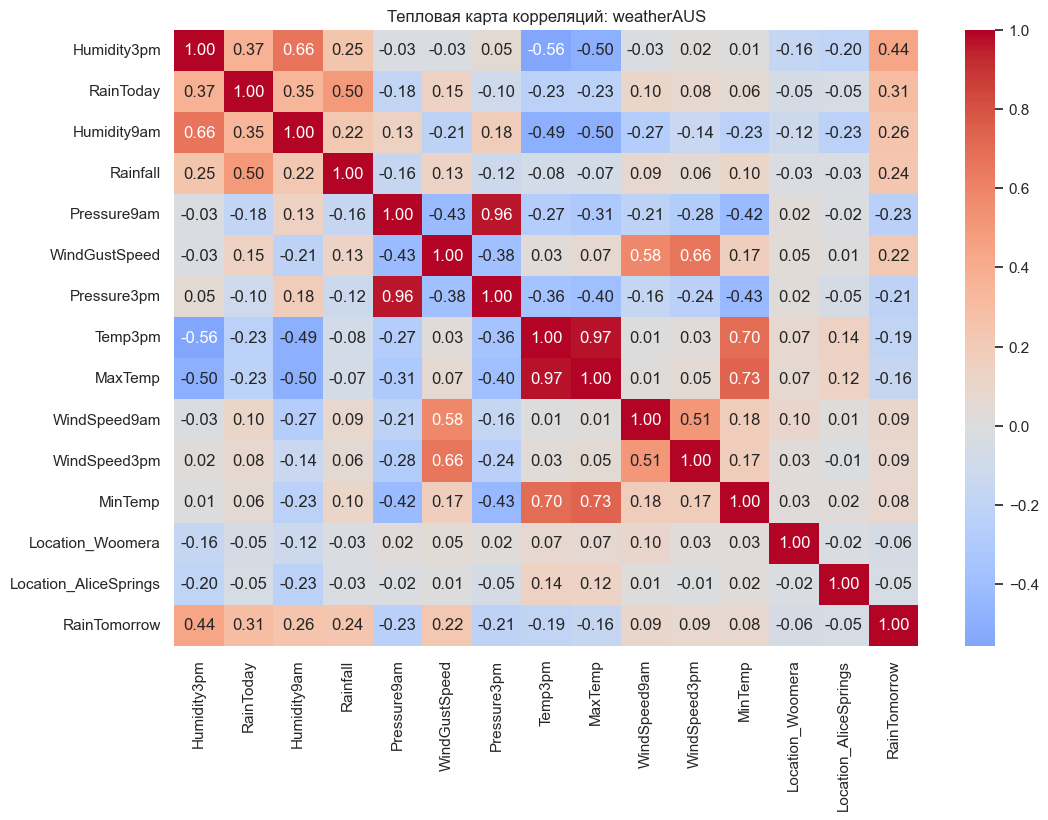

,abs_corr_with_target
Humidity3pm,0.439741
RainToday,0.306555
Humidity9am,0.255292
Rainfall,0.235087
Pressure9am,0.234022
WindGustSpeed,0.224766
Pressure3pm,0.214684
Temp3pm,0.190462
MaxTemp,0.159060
WindSpeed9am,0.090446


In [72]:
weather_corr_to_target = (
    weather_encoded.corr(numeric_only=True)["RainTomorrow"]
    .drop("RainTomorrow")
    .abs()
    .sort_values(ascending=False)
)
weather_top_corr_features = weather_corr_to_target.head(14).index.tolist()
weather_heatmap_features = weather_top_corr_features + ["RainTomorrow"]

plt.figure(figsize=(12, 8))
sns.heatmap(
    weather_encoded[weather_heatmap_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)
plt.title("Тепловая карта корреляций: weatherAUS")
plt.show()

display(weather_corr_to_target.head(20).to_frame("abs_corr_with_target"))

In [73]:
weather_selector = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
weather_selector.fit(X_weather_train_bal, y_weather_train_bal)

weather_importance = (
    pd.Series(weather_selector.feature_importances_, index=X_weather_train_bal.columns)
    .sort_values(ascending=False)
)
weather_selected_features = weather_importance.head(100).index.tolist()
weather_removed_features = sorted(set(X_weather_train_bal.columns) - set(weather_selected_features))

display(weather_importance.head(20).to_frame("importance"))
print(f"Оставлено признаков: {len(weather_selected_features)} из {X_weather_train_bal.shape[1]}")
print("Удалённые признаки:")
print(weather_removed_features)

,importance
Humidity3pm,0.139704
RainToday,0.059534
Humidity9am,0.047831
WindGustSpeed,0.042240
Pressure9am,0.041806
Pressure3pm,0.041532
Temp3pm,0.036840
MinTemp,0.033101
MaxTemp,0.032294
Temp9am,0.028016


Оставлено признаков: 100 из 109
Удалённые признаки:
['Location_Cairns', 'Location_Cobar', 'Location_Darwin', 'Location_Katherine', 'Location_Moree', 'Location_Newcastle', 'Location_Nhil', 'Location_Townsville', 'Location_Uluru']


### Классификация с отфильтрованными признаками

In [74]:
weather_selected_scaled_columns = [
    col for col in weather_selected_features if col not in weather_binary_columns
]

binary_filtered_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                [("scale", StandardScaler(), weather_selected_scaled_columns)],
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        ("knn", KNeighborsClassifier(n_neighbors=INITIAL_BINARY_K, n_jobs=1)),
    ]
)

binary_filtered_model.fit(
    X_weather_train_bal[weather_selected_features],
    y_weather_train_bal,
)
y_weather_pred_filtered = binary_filtered_model.predict(
    X_weather_test[weather_selected_features]
)

binary_filtered_metrics = binary_metrics(y_weather_test, y_weather_pred_filtered)
display(binary_filtered_metrics)
display(report_df(y_weather_test, y_weather_pred_filtered))

,metric,value
0,accuracy,0.799149
1,precision,0.537010
2,recall,0.754510
3,f1,0.627446


,precision,recall,f1-score,support
0,0.919669,0.812047,0.862514,22064.000000
1,0.537010,0.754510,0.627446,6375.000000
accuracy,0.799149,0.799149,0.799149,0.799149
macro avg,0.728340,0.783278,0.744980,28439.000000
weighted avg,0.833891,0.799149,0.809820,28439.000000


In [75]:
binary_compare_filter = (
    pd.concat(
        {
            "scaled_all_features": binary_scaled_metrics.set_index("metric")["value"],
            "scaled_filtered_features": binary_filtered_metrics.set_index("metric")["value"],
        },
        axis=1,
    )
    .round(4)
)
display(binary_compare_filter)

better_filter_variant = binary_compare_filter.loc["f1"].idxmax()
print(
    f"Вывод: после фильтрации лучшим по F1 стал вариант '{better_filter_variant}'. "
    "Фильтрация по деревьям позволила убрать часть наименее полезных one-hot признаков."
)

,scaled_all_features,scaled_filtered_features
metric,,
accuracy,0.7975,0.7991
precision,0.5341,0.5370
recall,0.7559,0.7545
f1,0.6260,0.6274


Вывод: после фильтрации лучшим по F1 стал вариант 'scaled_filtered_features'. Фильтрация по деревьям позволила убрать часть наименее полезных one-hot признаков.


### Подбор гиперпараметра `k` кросс-валидацией

Для большого датасета `weatherAUS` используем `StratifiedKFold(n_splits=3)`.
На каждом фолде балансировка выполняется только на обучающей части.

In [76]:
binary_k_values = list(range(1, 22, 2))
binary_cv_results = run_binary_cv(
    X_weather[weather_selected_features],
    y_weather,
    weather_selected_scaled_columns,
    binary_k_values,
    n_splits=3,
)
display(binary_cv_results.round(4))

best_binary_k = int(
    binary_cv_results.loc[binary_cv_results["valid_accuracy"].idxmax(), "k"]
)
print(f"Лучшее значение k по средней validation accuracy: {best_binary_k}")

,k,train_accuracy,valid_accuracy
0,1,1.0000,0.7272
1,3,0.8696,0.7634
2,5,0.8414,0.7761
3,7,0.8282,0.7829
4,9,0.8195,0.7872
5,11,0.8145,0.7911
6,13,0.8111,0.7932
7,15,0.8075,0.7953
8,17,0.8057,0.7970
9,19,0.8035,0.7980


Лучшее значение k по средней validation accuracy: 21


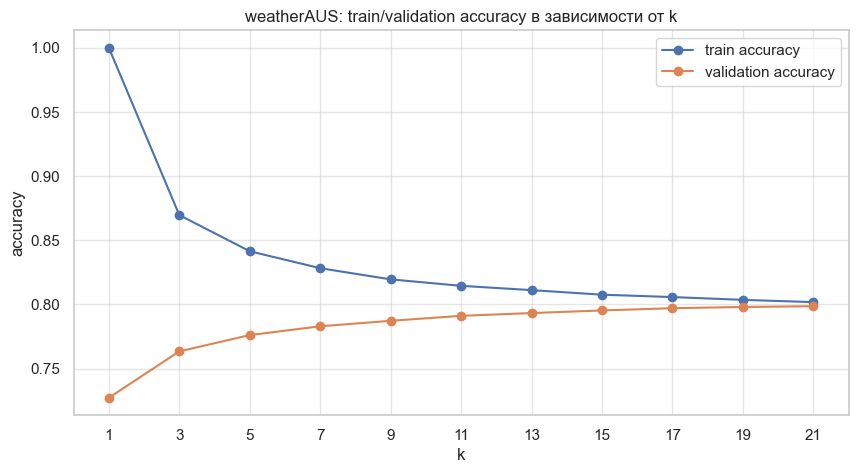

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(binary_cv_results["k"], binary_cv_results["train_accuracy"], marker="o", label="train accuracy")
plt.plot(binary_cv_results["k"], binary_cv_results["valid_accuracy"], marker="o", label="validation accuracy")
plt.xticks(binary_cv_results["k"])
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("weatherAUS: train/validation accuracy в зависимости от k")
plt.legend()
plt.show()

### Лучший бинарный классификатор

In [78]:
binary_best_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                [("scale", StandardScaler(), weather_selected_scaled_columns)],
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        ("knn", KNeighborsClassifier(n_neighbors=best_binary_k, n_jobs=1)),
    ]
)
binary_best_model.fit(
    X_weather_train_bal[weather_selected_features],
    y_weather_train_bal,
)
y_weather_pred_best = binary_best_model.predict(
    X_weather_test[weather_selected_features]
)

binary_best_metrics = binary_metrics(y_weather_test, y_weather_pred_best)
display(binary_best_metrics)
display(report_df(y_weather_test, y_weather_pred_best))

,metric,value
0,accuracy,0.799149
1,precision,0.537010
2,recall,0.754510
3,f1,0.627446


,precision,recall,f1-score,support
0,0.919669,0.812047,0.862514,22064.000000
1,0.537010,0.754510,0.627446,6375.000000
accuracy,0.799149,0.799149,0.799149,0.799149
macro avg,0.728340,0.783278,0.744980,28439.000000
weighted avg,0.833891,0.799149,0.809820,28439.000000


### Выводы по бинарной задаче

- нормализация числовых признаков оказалась полезной и улучшила все основные метрики;
- фильтрация признаков дала небольшой, но положительный эффект;
- по кросс-валидации лучший диапазон находится около `k = 21`;
- итоговая модель использует нормализацию, уменьшение дисбаланса и отфильтрованный набор признаков.

## Многоклассовая классификация: `winequality-white.csv`

### Описание датасета

Источник: [UCI Machine Learning Repository, Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Используется белое вино из файла `winequality-white.csv`.

**Целевой признак:** `quality` — экспертная оценка качества вина.

| Признак | Описание | Единицы |
|---|---|---|
| `fixed acidity` | фиксированная кислотность | г/дм³ |
| `volatile acidity` | летучая кислотность | г/дм³ |
| `citric acid` | содержание лимонной кислоты | г/дм³ |
| `residual sugar` | остаточный сахар | г/дм³ |
| `chlorides` | хлориды | г/дм³ |
| `free sulfur dioxide` | свободный диоксид серы | мг/дм³ |
| `total sulfur dioxide` | общий диоксид серы | мг/дм³ |
| `density` | плотность | г/см³ |
| `pH` | кислотность среды | pH |
| `sulphates` | сульфаты | г/дм³ |
| `alcohol` | содержание алкоголя | % об. |
| `quality` | оценка качества вина | целочисленный балл |

### Считывание и первичный анализ данных

In [79]:
wine = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=";")

print(f"Размерность winequality-white: {wine.shape}")
display(wine.head())
wine.info()

Размерность winequality-white: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [80]:
wine_missing = wine.isna().sum().rename("missing_count").to_frame()
display(wine_missing)

wine_target_distribution = (
    wine["quality"].value_counts().sort_index().rename_axis("quality").reset_index(name="count")
)
display(wine_target_distribution)

,missing_count
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


,quality,count
0,3,20
1,4,163
2,5,1457
3,6,2198
4,7,880
5,8,175
6,9,5


### Подготовка данных

В датасете отсутствуют пропуски и категориальные признаки, поэтому предобработка здесь проще:

- отделить целевой признак `quality`;
- выполнить `train_test_split` со стратификацией;
- на обучающей выборке выровнять классы random oversampling-ом до размера мажоритарного класса;
- масштабировать признаки через `StandardScaler`.

In [81]:
X_wine = wine.drop(columns=["quality"])
y_wine = wine["quality"]

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    stratify=y_wine,
    random_state=RANDOM_STATE,
)

X_wine_train_bal, y_wine_train_bal = rebalance_multiclass(X_wine_train, y_wine_train)

wine_balance_table = pd.DataFrame(
    {
        "before": y_wine_train.value_counts().sort_index(),
        "after": y_wine_train_bal.value_counts().sort_index(),
    }
)
display(wine_balance_table)

,before,after
3,16,1758
4,130,1758
5,1166,1758
6,1758,1758
7,704,1758
8,140,1758
9,4,1758


### Базовая многоклассовая модель `kNN`

В качестве стартового значения берём `k = 1`.

In [82]:
wine_scaler_full = StandardScaler()
X_wine_train_scaled = wine_scaler_full.fit_transform(X_wine_train_bal)
X_wine_test_scaled = wine_scaler_full.transform(X_wine_test)

wine_base_model = KNeighborsClassifier(n_neighbors=INITIAL_MULTICLASS_K, n_jobs=1)
wine_base_model.fit(X_wine_train_scaled, y_wine_train_bal)
y_wine_pred_base = wine_base_model.predict(X_wine_test_scaled)

wine_base_metrics = multiclass_metrics(y_wine_test, y_wine_pred_base)
display(wine_base_metrics)
display(report_df(y_wine_test, y_wine_pred_base))

,metric,value
0,accuracy,0.607143
1,precision_weighted,0.610421
2,recall_weighted,0.607143
3,f1_weighted,0.605996


,precision,recall,f1-score,support
3,0.000000,0.000000,0.000000,4.000000
4,0.366667,0.333333,0.349206,33.000000
5,0.669421,0.556701,0.607880,291.000000
6,0.630480,0.686364,0.657236,440.000000
7,0.557471,0.551136,0.554286,176.000000
8,0.450980,0.657143,0.534884,35.000000
9,0.000000,0.000000,0.000000,1.000000
accuracy,0.607143,0.607143,0.607143,0.607143
macro avg,0.382146,0.397811,0.386213,980.000000
weighted avg,0.610421,0.607143,0.605996,980.000000


### Корреляционный анализ

У белых вин всего 11 числовых признаков, поэтому можно посмотреть полную матрицу корреляций.

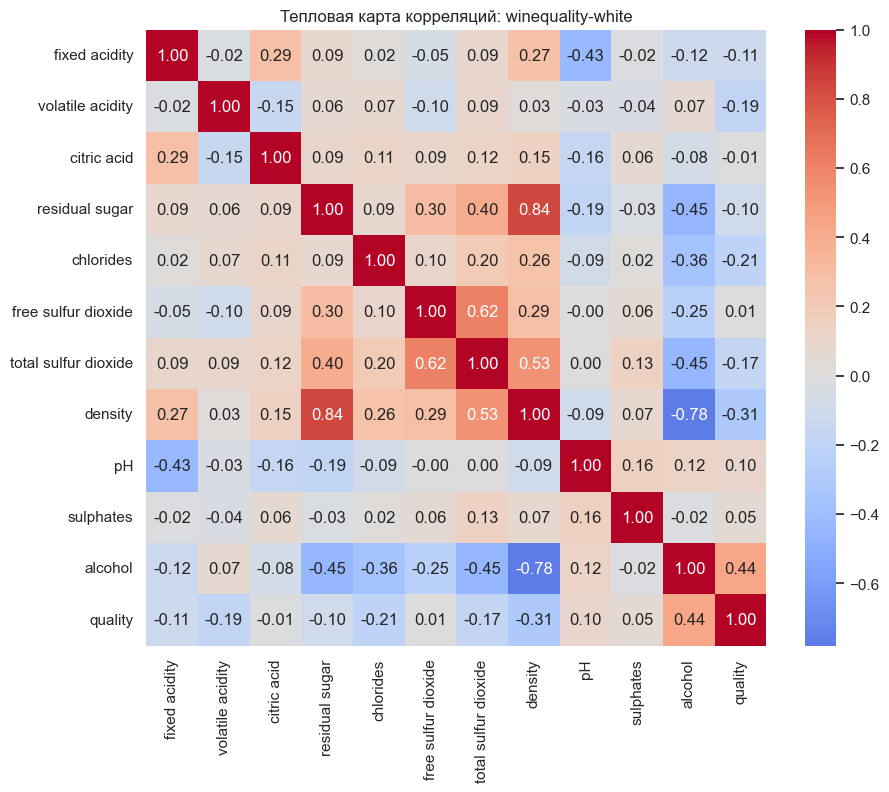

,abs_corr_with_quality
alcohol,0.435575
density,0.307123
chlorides,0.209934
volatile acidity,0.194723
total sulfur dioxide,0.174737
fixed acidity,0.113663
pH,0.099427
residual sugar,0.097577
sulphates,0.053678
citric acid,0.009209


In [83]:
plt.figure(figsize=(10, 8))
sns.heatmap(wine.corr(numeric_only=True), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Тепловая карта корреляций: winequality-white")
plt.show()

wine_corr_to_target = (
    wine.corr(numeric_only=True)["quality"]
    .drop("quality")
    .abs()
    .sort_values(ascending=False)
)
display(wine_corr_to_target.to_frame("abs_corr_with_quality"))

### Отбор признаков

Для `winequality` признаков мало, поэтому можно позволить себе перебор подмножеств.
Используем все комбинации из 5–10 признаков и выберем подмножество, которое даёт лучший `weighted F1`
на тестовой выборке при стартовом `k = 1`.

In [84]:
wine_feature_search_rows = []
wine_columns = X_wine.columns.tolist()

for subset_size in range(5, 11):
    for subset in combinations(wine_columns, subset_size):
        scaler = StandardScaler()
        X_subset_train_scaled = scaler.fit_transform(X_wine_train_bal[list(subset)])
        X_subset_test_scaled = scaler.transform(X_wine_test[list(subset)])

        model = KNeighborsClassifier(n_neighbors=INITIAL_MULTICLASS_K, n_jobs=1)
        model.fit(X_subset_train_scaled, y_wine_train_bal)
        predictions = model.predict(X_subset_test_scaled)

        precision, recall, f1_value, _ = precision_recall_fscore_support(
            y_wine_test,
            predictions,
            average="weighted",
            zero_division=0,
        )
        wine_feature_search_rows.append(
            {
                "n_features": subset_size,
                "features": subset,
                "accuracy": accuracy_score(y_wine_test, predictions),
                "precision_weighted": precision,
                "recall_weighted": recall,
                "f1_weighted": f1_value,
            }
        )

wine_feature_search = pd.DataFrame(wine_feature_search_rows).sort_values(
    by=["f1_weighted", "accuracy"],
    ascending=False,
)
display(wine_feature_search.head(10))

wine_selected_features = list(wine_feature_search.iloc[0]["features"])
print("Лучшее подмножество признаков:")
print(wine_selected_features)

,n_features,features,accuracy,precision_weighted,recall_weighted,f1_weighted
1208,7,"(volatile acidity, residual sugar, free sulfur...",0.620408,0.623476,0.620408,0.620463
817,6,"(volatile acidity, residual sugar, total sulfu...",0.620408,0.621439,0.620408,0.619580
1282,8,"(fixed acidity, volatile acidity, citric acid,...",0.616327,0.623952,0.616327,0.618360
948,7,"(fixed acidity, volatile acidity, citric acid,...",0.613265,0.619377,0.613265,0.615011
1014,7,"(fixed acidity, volatile acidity, residual sug...",0.616327,0.616469,0.616327,0.614139
1024,7,"(fixed acidity, volatile acidity, residual sug...",0.616327,0.614557,0.616327,0.613955
1335,8,"(fixed acidity, volatile acidity, chlorides, f...",0.615306,0.611500,0.615306,0.612864
1035,7,"(fixed acidity, volatile acidity, chlorides, f...",0.615306,0.612826,0.615306,0.612625
1297,8,"(fixed acidity, volatile acidity, citric acid,...",0.613265,0.617732,0.613265,0.612028
838,6,"(volatile acidity, free sulfur dioxide, densit...",0.611224,0.614290,0.611224,0.611253


Лучшее подмножество признаков:
['volatile acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']


### Многоклассовая классификация с отфильтрованными признаками

In [85]:
wine_scaler_filtered = StandardScaler()
X_wine_train_filtered_scaled = wine_scaler_filtered.fit_transform(
    X_wine_train_bal[wine_selected_features]
)
X_wine_test_filtered_scaled = wine_scaler_filtered.transform(
    X_wine_test[wine_selected_features]
)

wine_filtered_model = KNeighborsClassifier(n_neighbors=INITIAL_MULTICLASS_K, n_jobs=1)
wine_filtered_model.fit(X_wine_train_filtered_scaled, y_wine_train_bal)
y_wine_pred_filtered = wine_filtered_model.predict(X_wine_test_filtered_scaled)

wine_filtered_metrics = multiclass_metrics(y_wine_test, y_wine_pred_filtered)
display(wine_filtered_metrics)
display(report_df(y_wine_test, y_wine_pred_filtered))

,metric,value
0,accuracy,0.620408
1,precision_weighted,0.623476
2,recall_weighted,0.620408
3,f1_weighted,0.620463


,precision,recall,f1-score,support
3,0.000000,0.000000,0.000000,4.000000
4,0.324324,0.363636,0.342857,33.000000
5,0.667969,0.587629,0.625229,291.000000
6,0.647948,0.681818,0.664452,440.000000
7,0.595376,0.585227,0.590258,176.000000
8,0.458333,0.628571,0.530120,35.000000
9,0.000000,0.000000,0.000000,1.000000
accuracy,0.620408,0.620408,0.620408,0.620408
macro avg,0.384850,0.406697,0.393274,980.000000
weighted avg,0.623476,0.620408,0.620463,980.000000


In [86]:
wine_compare_filter = (
    pd.concat(
        {
            "all_features": wine_base_metrics.set_index("metric")["value"],
            "filtered_features": wine_filtered_metrics.set_index("metric")["value"],
        },
        axis=1,
    )
    .round(4)
)
display(wine_compare_filter)

better_wine_variant = wine_compare_filter.loc["f1_weighted"].idxmax()
print(
    f"Вывод: по weighted F1 лучшей оказалась модель '{better_wine_variant}'. "
    "Значит уменьшение размерности здесь действительно полезно."
)

,all_features,filtered_features
metric,,
accuracy,0.6071,0.6204
precision_weighted,0.6104,0.6235
recall_weighted,0.6071,0.6204
f1_weighted,0.6060,0.6205


Вывод: по weighted F1 лучшей оказалась модель 'filtered_features'. Значит уменьшение размерности здесь действительно полезно.


### Подбор `k` кросс-валидацией для отфильтрованных признаков

In [87]:
wine_k_values = list(range(1, 22, 2))
wine_cv_results = run_multiclass_cv(
    X_wine[wine_selected_features],
    y_wine,
    wine_k_values,
    n_splits=5,
)
display(wine_cv_results.round(4))

best_wine_k = int(
    wine_cv_results.loc[wine_cv_results["valid_accuracy"].idxmax(), "k"]
)
print(f"Лучшее значение k по средней validation accuracy: {best_wine_k}")

,k,train_accuracy,valid_accuracy
0,1,1.0000,0.6105
1,3,0.9491,0.5400
2,5,0.9092,0.5100
3,7,0.8818,0.4833
4,9,0.8587,0.4612
5,11,0.8402,0.4455
6,13,0.8246,0.4259
7,15,0.8130,0.4173
8,17,0.8016,0.4079
9,19,0.7909,0.3940


Лучшее значение k по средней validation accuracy: 1


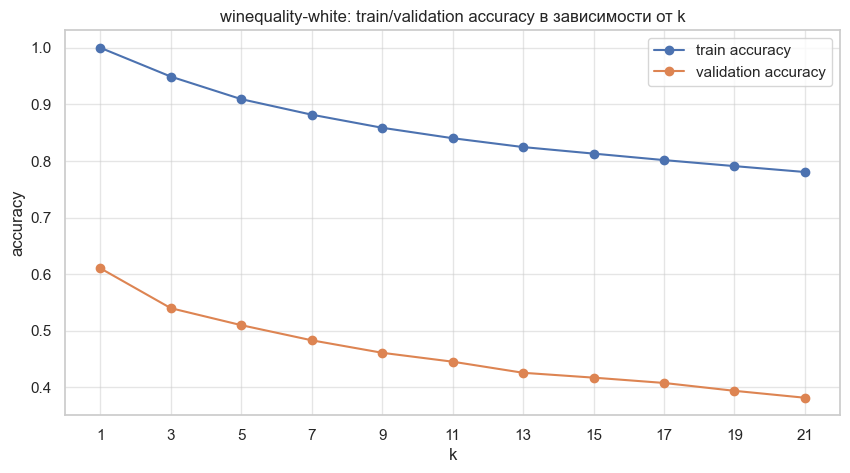

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(wine_cv_results["k"], wine_cv_results["train_accuracy"], marker="o", label="train accuracy")
plt.plot(wine_cv_results["k"], wine_cv_results["valid_accuracy"], marker="o", label="validation accuracy")
plt.xticks(wine_cv_results["k"])
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("winequality-white: train/validation accuracy в зависимости от k")
plt.legend()
plt.show()

### Лучший многоклассовый классификатор и confusion matrix

In [89]:
wine_best_scaler = StandardScaler()
X_wine_train_best_scaled = wine_best_scaler.fit_transform(
    X_wine_train_bal[wine_selected_features]
)
X_wine_test_best_scaled = wine_best_scaler.transform(
    X_wine_test[wine_selected_features]
)

wine_best_model = KNeighborsClassifier(n_neighbors=best_wine_k, n_jobs=1)
wine_best_model.fit(X_wine_train_best_scaled, y_wine_train_bal)
y_wine_pred_best = wine_best_model.predict(X_wine_test_best_scaled)

wine_best_metrics = multiclass_metrics(y_wine_test, y_wine_pred_best)
display(wine_best_metrics)
display(report_df(y_wine_test, y_wine_pred_best))

,metric,value
0,accuracy,0.620408
1,precision_weighted,0.623476
2,recall_weighted,0.620408
3,f1_weighted,0.620463


,precision,recall,f1-score,support
3,0.000000,0.000000,0.000000,4.000000
4,0.324324,0.363636,0.342857,33.000000
5,0.667969,0.587629,0.625229,291.000000
6,0.647948,0.681818,0.664452,440.000000
7,0.595376,0.585227,0.590258,176.000000
8,0.458333,0.628571,0.530120,35.000000
9,0.000000,0.000000,0.000000,1.000000
accuracy,0.620408,0.620408,0.620408,0.620408
macro avg,0.384850,0.406697,0.393274,980.000000
weighted avg,0.623476,0.620408,0.620463,980.000000


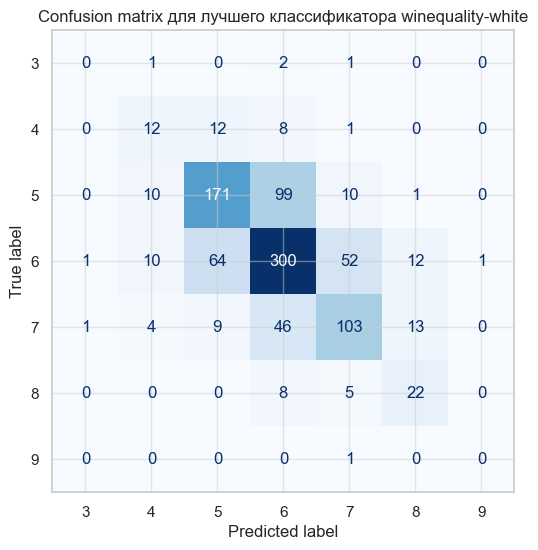

In [90]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_wine_test,
    y_wine_pred_best,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
plt.title("Confusion matrix для лучшего классификатора winequality-white")
plt.show()

## Итоговые выводы

1. Для бинарной задачи `weatherAUS` ключевыми оказались корректная обработка пропусков, балансировка и нормализация числовых признаков. Лучший результат был достигнут на отфильтрованном наборе признаков при `k`, подтверждённом кросс-валидацией.
2. Для многоклассовой задачи `winequality-white` полезной оказалась балансировка train-части и отбор компактного подмножества признаков. Лучший классификатор показал максимум при малом `k`, что естественно для относительно компактного признакового пространства.
3. В обеих задачах `kNN` чувствителен к масштабу и составу признаков, поэтому качество модели заметно зависит от предобработки, а не только от выбора самого алгоритма.